In [1]:
import torch
import matplotlib.pyplot as plt
import os
import numpy as np
import sklearn
import rich
import sklearn
import pandas as pd

from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from rich.progress import Progress
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torchinfo import summary
from torch import nn
from torch.utils.data import DataLoader, Subset

plt.style.use('ggplot')

# Exploratory Data Analysis

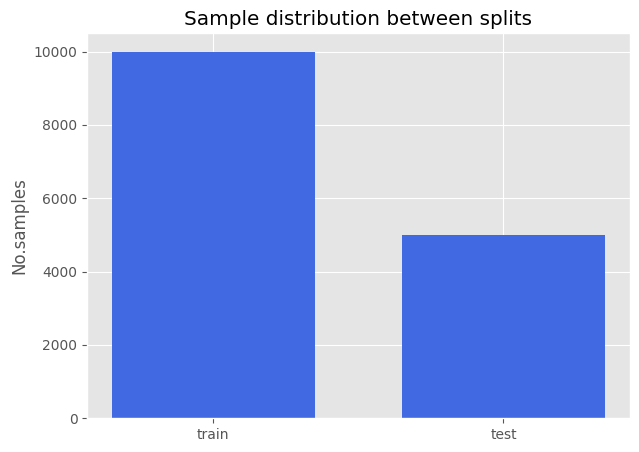

In [2]:
# Check the sample distribution between train and test set
DATA_PATH = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data"
sample_distribution = {}

for split in ['train', 'test']:
    total_sample = 0
    FOLDER_PATH = os.path.join(DATA_PATH, split)

    for class_name in os.listdir(FOLDER_PATH):
        CLASS_PATH = os.path.join(FOLDER_PATH, class_name)
        total_sample += len(os.listdir(CLASS_PATH))

    sample_distribution[split] = total_sample

# Plot the sample distribution
plt.figure(figsize=(7, 5))
plt.bar(sample_distribution.keys(), sample_distribution.values(), color='royalblue', width=0.7)
plt.title("Sample distribution between splits")
plt.ylabel("No.samples")
plt.show()

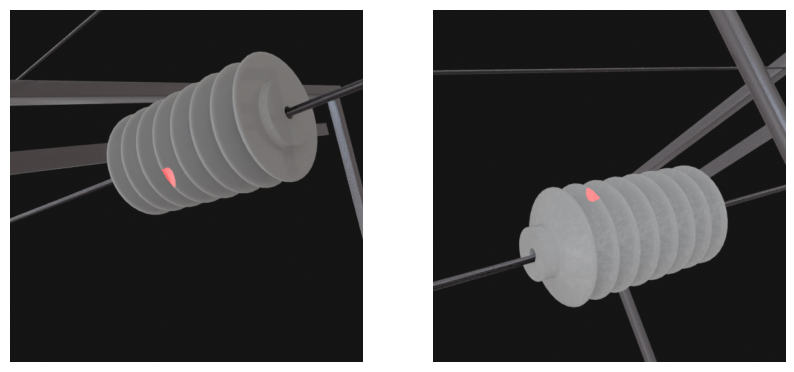

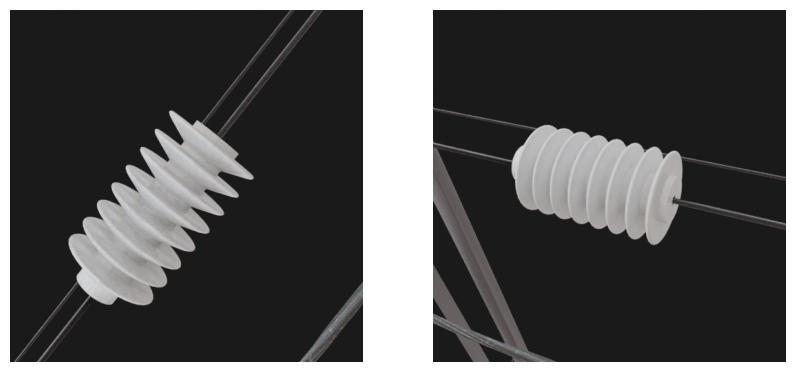

In [3]:
# Display example images
FOLDER_PATH = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/test"
MASK_FOLDER = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/ground_truth/broken"

for class_name in os.listdir(FOLDER_PATH):
    CLASS_PATH = os.path.join(FOLDER_PATH, class_name)

    # Visualize 2 images in each class
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(10, 5))
    for i in range(2):
        IMG_NAME = os.listdir(CLASS_PATH)[i]
        IMG_PATH = os.path.join(CLASS_PATH, IMG_NAME)
        image = plt.imread(IMG_PATH)

        # If defective, show broken location
        if class_name == "broken":
            alpha = 0.2 # Transparency
            MASK_NAME = f"{IMG_NAME[:-4]}_mask.png" # Get corresponding mask
            MASK_PATH = os.path.join(MASK_FOLDER, MASK_NAME)

            # Overlay mask onto image
            temp = plt.imread(MASK_PATH)
            mask = np.zeros(image.shape)
            mask[:, :, 0] = temp * 255
            image = (1 - alpha) * image + alpha * mask
            image = np.clip(image, 0, 1) # Ensure pixel value is still within range 0 - 255 after overlay

        ax[i].imshow(image)
        ax[i].axis("off")

plt.show()

In [4]:
# Check image dimension
image.shape

(512, 512, 3)

# Model Building

In [5]:
# Set random seed for reproducibility
RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

## One-Class SVM

In [6]:
# Load dataset
TRAIN_FOLDER = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/train"
TEST_FOLDER = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/test"

# Split original train dataset into train and val dataset
WEIGHTS = ResNet18_Weights.DEFAULT
temp_dataset = datasets.ImageFolder(TRAIN_FOLDER, transform=WEIGHTS.transforms())
sample_indices = list(range(len(temp_dataset.targets)))

train_indices, val_indices = train_test_split(sample_indices, test_size=0.3)
train_dataset = Subset(temp_dataset, train_indices)
val_dataset = Subset(temp_dataset, val_indices)
test_dataset = datasets.ImageFolder(TEST_FOLDER, transform=WEIGHTS.transforms())

# Create Dataloader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, drop_last=False)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False, drop_last=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [7]:
model = resnet18(weights=WEIGHTS, progress=True)
feature_extractor = nn.Sequential(*list(model.children())[:-1]) # Get every layer except the last fc layer

for param in feature_extractor.parameters():
  param.requires_grad = False
  
summary(feature_extractor, input_size=(32, 3, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s] 


Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 512, 1, 1]           --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]  

In [8]:
def extract_feature_vector(dataset) -> torch.Tensor:
  feature_vector = []
  labels = []
    
  for i in range(len(dataset)):
    image, label = dataset[i]
    labels.append(label)
      
    image = image.to(device='cuda')
    image = image.unsqueeze(0)  # [3,224,224] -> [1,3,224,224]
      
    features = feature_extractor(image)
    features = features.flatten(start_dim=1)  # [1,512,1,1] -> [1,512]
    feature_vector.extend(features.cpu().numpy())
      
  return np.array(feature_vector), np.array(labels)

In [9]:
train_features, train_labels = extract_feature_vector(train_dataset)
val_features, val_labels = extract_feature_vector(val_dataset)
test_features, test_labels = extract_feature_vector(test_dataset)

print(train_features.shape, train_labels.shape)
print(val_features.shape, val_labels.shape)
print(test_features.shape, test_labels.shape)

(7000, 512) (7000,)
(3000, 512) (3000,)
(5000, 512) (5000,)


In [10]:

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)

## Convolutional autoencoder

In [16]:
# Load dataset
TRAIN_FOLDER = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/train"
TEST_FOLDER = r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/test"

# Split original train dataset into train and val dataset
temp_dataset = datasets.ImageFolder(TRAIN_FOLDER, transform=transforms.ToTensor())
sample_indices = list(range(len(temp_dataset.targets)))

train_indices, val_indices = train_test_split(sample_indices, test_size=0.3)
train_dataset = Subset(temp_dataset, train_indices)
val_dataset = Subset(temp_dataset, val_indices)
test_dataset = datasets.ImageFolder(TEST_FOLDER, transform=transforms.ToTensor())

# Create Dataloader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, drop_last=False)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False, drop_last=False)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [17]:
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2),

                                     nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2),

                                     nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2),

                                     nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2, stride=2))

        # Decoder
        self.decoder = nn.Sequential(nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.ReLU(),

                                     nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.ReLU(),

                                     nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.ReLU(),

                                     nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
                                     nn.Sigmoid()) # Use Sigmoid to ensure reconstructed pixel between 0 and 1

    def forward(self, x):
        x = self.encoder(x)
        x_reconstructed = self.decoder(x)

        return x_reconstructed

In [18]:
# Check if output shape is correct
model = ConvAutoEncoder()
summary(model, input_size=(32, 3, 512, 512))

Layer (type:depth-idx)                   Output Shape              Param #
ConvAutoEncoder                          [32, 3, 512, 512]         --
├─Sequential: 1-1                        [32, 256, 32, 32]         --
│    └─Conv2d: 2-1                       [32, 32, 512, 512]        896
│    └─ReLU: 2-2                         [32, 32, 512, 512]        --
│    └─MaxPool2d: 2-3                    [32, 32, 256, 256]        --
│    └─Conv2d: 2-4                       [32, 64, 256, 256]        18,496
│    └─ReLU: 2-5                         [32, 64, 256, 256]        --
│    └─MaxPool2d: 2-6                    [32, 64, 128, 128]        --
│    └─Conv2d: 2-7                       [32, 128, 128, 128]       73,856
│    └─ReLU: 2-8                         [32, 128, 128, 128]       --
│    └─MaxPool2d: 2-9                    [32, 128, 64, 64]         --
│    └─Conv2d: 2-10                      [32, 256, 64, 64]         295,168
│    └─ReLU: 2-11                        [32, 256, 64, 64]         --
│

# Model Training

## One-Class SVM

In [11]:
ocsvm.fit(train_features)

OneClassSVM(nu=0.05)

## Convolutional autoencoder

In [19]:
# Set up hyperparameters
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 0.01
OPTIMIZER= torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
LOSS_FN = nn.MSELoss()
PATIENCE = 20
BEST_VAL_SCORE = float("inf")
NO_IMPROVE = 0
EPOCHS = 200
SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=OPTIMIZER, mode='min', factor=0.1, patience=PATIENCE/2)
SAVE_PATH = r"/content/data/autoencoder_weights.pt"

In [20]:
# Training loop
model.to(device=DEVICE)
loss_over_time = [] # [(train_loss_epoch0, val_loss_epoch0), (train_loss_epoch1, val_loss_epoch1), ...]

with Progress() as progress:
    epoch_counter = progress.add_task(description="EPOCH", total=EPOCHS)
    train_batch_counter = progress.add_task(description="TRAIN_BATCH", total=len(train_dataloader))
    val_batch_counter = progress.add_task(description="VAL_BATCH", total=len(val_dataloader))

    for epoch in range(EPOCHS):
        # ============================== TRAIN ==================================
        train_loss_avg = 0
        val_loss_avg = 0

        for images, _ in train_dataloader:
            images = images.to(device=DEVICE)

            model.train()
            images_reconstructed = model(images)
            train_loss = LOSS_FN(images_reconstructed, images)
            train_loss_avg += train_loss.item()
            OPTIMIZER.zero_grad()
            train_loss.backward()
            OPTIMIZER.step()
            progress.update(train_batch_counter, advance=1)

        train_loss_avg /= len(train_dataloader)

        # ================================= VAL ================================
        model.eval()

        with torch.inference_mode():
            for images, _ in val_dataloader:
                images = images.to(device=DEVICE)

                images_reconstructed = model(images)
                val_loss = LOSS_FN(images_reconstructed, images)
                val_loss_avg += val_loss.item()
                progress.update(val_batch_counter, advance=1)

            val_loss_avg /= len(val_dataloader)
            SCHEDULER.step(val_loss_avg)
            loss_over_time.append((train_loss_avg, val_loss_avg))

            # ======================== EARLY STOPPING ===========================
            if val_loss_avg < BEST_VAL_SCORE:
                BEST_VAL_SCORE = val_loss_avg
                NO_IMPROVE = 0
                torch.save(model.state_dict(), SAVE_PATH)
            else:
                NO_IMPROVE += 1

            if NO_IMPROVE > PATIENCE:
                print("Early stopping triggered")
                break

            # ===================== DISPLAY RECONSTRUCTED IMAGE ========================
            if epoch % 20 == 0:
              # Take 1 image to display
              example_original = images[0]
              example_reconstructed = model(example_original).permute(1, 2, 0).cpu()
              example_original = example_original.permute(1, 2, 0).cpu() # Permute to change from C x H x W to H x W x C for matplotlib display

              fig, ax = plt.subplots(nrows=1, ncols=2)
              ax[0].imshow(example_original)
              ax[0].set_title(f"Original (Epoch = {epoch})")
              ax[0].axis("off")
              ax[1].imshow(example_reconstructed)
              ax[1].set_title(f"Reconstructed (Epoch = {epoch})")
              ax[1].axis("off")
              plt.show()

        progress.update(epoch_counter, advance=1)
        progress.reset(train_batch_counter)
        progress.reset(val_batch_counter)

Output()

KeyboardInterrupt: 

In [ ]:
# Save the training and val loss
with open(r"/kaggle/input/datasets/uts3125024902037/loss-over-time/loss.txt", 'w') as file:
  for loss in loss_over_time:
    file.write(str(loss) + "\n")

In [21]:
with open(r"/kaggle/input/datasets/uts3125024902037/loss-over-time/loss.txt", 'r') as file:
  loss_over_time = file.read().strip("\n").split("\n")

loss_over_time = [tuple((map(float, loss.strip("()").split(",")))) for loss in loss_over_time]

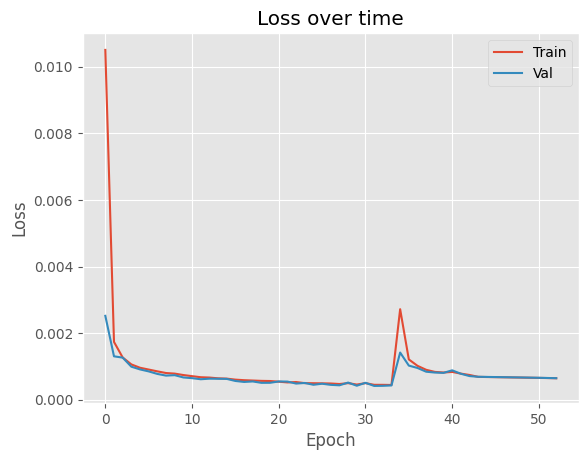

In [22]:
plt.title("Loss over time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(loss_over_time)), [loss[0] for loss in loss_over_time], label="Train")
plt.plot(range(len(loss_over_time)), [loss[1] for loss in loss_over_time], label="Val")
plt.legend()
plt.show()

# Model Testing

## One-Class SVM

In [12]:
# For the train and val dataset, good = 0
# For the test dataset, broken = 0 and good = 1
# The model outputs 1 for normal and -1 for anomalies
train_predict = ocsvm.predict(train_features)
train_predict = np.where(train_predict == 1, 0, 1)
train_result = pd.DataFrame(classification_report(train_labels, train_predict, target_names=["Good", "Defective"], output_dict=True))

val_predict = ocsvm.predict(val_features)
val_predict = np.where(val_predict == 1, 0, 1)
val_result = pd.DataFrame(classification_report(val_labels, val_predict, target_names=["Good", "Defective"], output_dict=True))

test_predict = ocsvm.predict(test_features) == 1
test_result = pd.DataFrame(classification_report(test_labels, test_predict, target_names=["Defective", "Good"], output_dict=True))


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

In [13]:
train_result

,Good,Defective,accuracy,macro avg,weighted avg
precision,1.000000,0.0,0.949857,0.500000,1.000000
recall,0.949857,0.0,0.949857,0.474929,0.949857
f1-score,0.974284,0.0,0.949857,0.487142,0.974284
support,7000.000000,0.0,0.949857,7000.000000,7000.000000


In [14]:
val_result

,Good,Defective,accuracy,macro avg,weighted avg
precision,1.000000,0.0,0.946667,0.500000,1.000000
recall,0.946667,0.0,0.946667,0.473333,0.946667
f1-score,0.972603,0.0,0.946667,0.486301,0.972603
support,3000.000000,0.0,0.946667,3000.000000,3000.000000


In [15]:
test_result

,Defective,Good,accuracy,macro avg,weighted avg
precision,0.547529,0.502639,0.505,0.525084,0.525084
recall,0.057600,0.952400,0.505,0.505000,0.505000
f1-score,0.104235,0.658007,0.505,0.381121,0.381121
support,2500.000000,2500.000000,0.505,5000.000000,5000.000000


## Convolutional autoencoder

In [23]:
# Load the trained weights in
WEIGHT_PATH = r"/kaggle/input/datasets/uts3125024902037/autoencoder-weights/autoencoder_weights.pt"
model = ConvAutoEncoder()
model.load_state_dict(torch.load(WEIGHT_PATH, weights_only=True, map_location=torch.device('cpu')))
model.eval()

ConvAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=

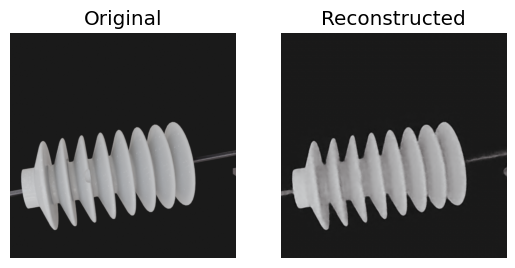

In [25]:
# See if the model will reconstruct a good electrical insulator from a defective one
with torch.inference_mode():
  fig, ax = plt.subplots(nrows=1, ncols=2)
  example_original = plt.imread(r"/kaggle/input/datasets/uts3125024902037/electrical-insulator/data/test/broken/000000.png")
  ax[0].imshow(example_original)
  ax[0].set_title(f"Original")
  ax[0].axis("off")


  example_original = transforms.ToTensor()(example_original)
  example_reconstructed = model(example_original).permute(1, 2, 0)
  ax[1].imshow(example_reconstructed)
  ax[1].set_title(f"Reconstructed")
  ax[1].axis("off")
  plt.show()

In [26]:
# Calculate the mean and standard deviation of the reconstruction error of the good parts
# Then we detect if a part is an anomaly or not if its reconstruction error is more than 2 standard deviations away
# from the mean

# Put model to GPU for faster inference
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LOSS_FN = nn.MSELoss()
model.to(device=DEVICE)
reconstruction_loss_per_image = []

with torch.inference_mode():
  for i in range(len(val_dataset)):
    image, _ = val_dataset[i]
    image = image.to(device=DEVICE)

    reconstructed_image = model(image)
    loss = LOSS_FN(reconstructed_image, image)
    reconstruction_loss_per_image.append(loss.item())

reconstruction_loss_per_image = np.array(reconstruction_loss_per_image)
mean_reconstruction_error = np.mean(reconstruction_loss_per_image)
std_reconstruction_error = np.std(reconstruction_loss_per_image, ddof=1)
threshold = mean_reconstruction_error + 2 *std_reconstruction_error

print(f"Mean reconstruction error: {mean_reconstruction_error}")
print(f"Standard deviation of reconstruction error: {std_reconstruction_error}")
print(f"Threshold: {threshold}")

Mean reconstruction error: 0.00040836175410125485
Standard deviation of reconstruction error: 9.992313346534796e-05
Threshold: 0.0006082080210319508


In [27]:
# Using the calculated mean and std of the reconstruction error of the good part to detect anomaly
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LOSS_FN = nn.MSELoss()
model.to(device=DEVICE)
test_error = []
defective_error = [] # Record the reconstruction error of the defective class to compare the error distribution between good vs defective later
ground_truth = []

with torch.inference_mode():
  for i in range(len(test_dataset)):
    image, label = test_dataset[i]
    ground_truth.append(label)
    image = image.to(device=DEVICE)

    reconstructed_image = model(image)
    loss = LOSS_FN(reconstructed_image, image)
    test_error.append(loss.item())

    if label == 0:
      defective_error.append(loss.item())

test_error = np.array(test_error)
# Class mapping is broken = 0 and good = 1
# >> test_dataset.class_to_idx gives {'broken': 0, 'good': 1}
# Since anomalies are likely to have high reconstruction error, if it's above threshold it's likely to be a defective
# But that gives us label 1 instead of 0 like the mapping, so we have to perform logical NOT
model_predictions = np.logical_not(test_error > threshold).astype(int)
result = pd.DataFrame(classification_report(ground_truth, model_predictions, target_names=["Defective", "Good"], output_dict=True))

In [28]:
result

,Defective,Good,accuracy,macro avg,weighted avg
precision,0.460674,0.498548,0.4972,0.479611,0.479611
recall,0.032800,0.961600,0.4972,0.497200,0.497200
f1-score,0.061240,0.656651,0.4972,0.358945,0.358945
support,2500.000000,2500.000000,0.4972,5000.000000,5000.000000


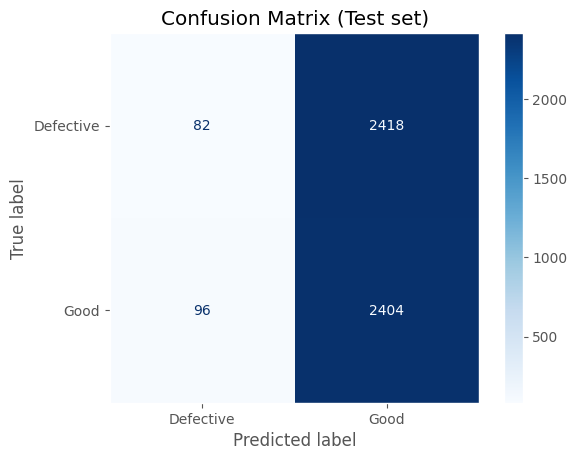

In [29]:
cm = confusion_matrix(ground_truth, model_predictions, labels=[0, 1])
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Defective", "Good"])
display.plot(cmap="Blues")
display.ax_.grid(False)
display.ax_.set_title("Confusion Matrix (Test set)")
plt.show()

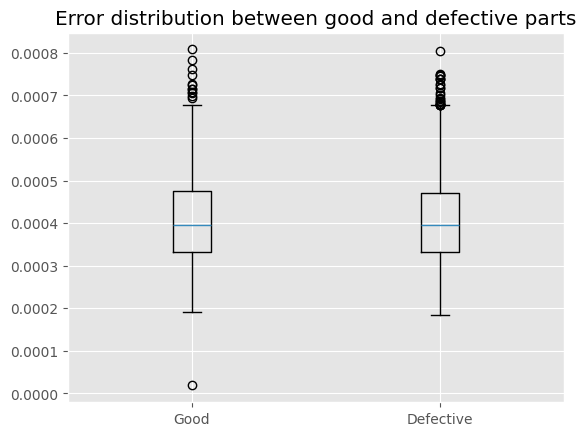

In [31]:
plt.boxplot([reconstruction_loss_per_image, defective_error], tick_labels=["Good", "Defective"])
plt.title("Error distribution between good and defective parts")
plt.show()